In [521]:
!pip install catboost
!pip install xgboost

In [522]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    recall_score,
    f1_score,
    log_loss,
    classification_report,
    hinge_loss
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

In [523]:
df = pd.read_csv('loan_approval_dataset.csv')

df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [524]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4269, 13)


In [525]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [526]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [527]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

In [528]:
if 'loan_id' in df.columns:
    df.drop('loan_id', axis=1, inplace=True)

print(df.columns.tolist())

['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [529]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


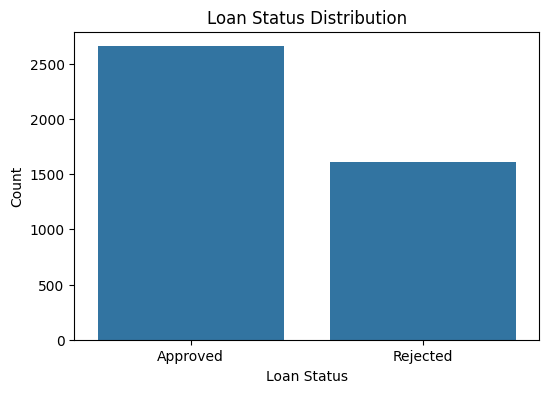

In [530]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='loan_status',
    data=df
)

plt.title('Loan Status Distribution')

plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [531]:
print("Missing Values Count:")

print(df.isnull().sum())

Missing Values Count:
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [532]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [533]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
Index(['education', 'self_employed', 'loan_status'], dtype='object')

Numerical Columns:
Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')


In [534]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [535]:
print("Missing Values After Cleaning:")

print(df.isnull().sum())

Missing Values After Cleaning:
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [536]:
df['loan_status'] = df['loan_status'].str.strip().map({
    'Approved': 1,
    'Rejected': 0
})

In [537]:
print(df['loan_status'].value_counts())

loan_status
1    2656
0    1613
Name: count, dtype: int64


In [538]:
#Balance Analysis

In [539]:
class_counts = df['loan_status'].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
loan_status
1    2656
0    1613
Name: count, dtype: int64


In [540]:
class_percentages = df['loan_status'].value_counts(
    normalize=True
) * 100

print("Class Distribution Percentage:")
print(class_percentages)

Class Distribution Percentage:
loan_status
1    62.215976
0    37.784024
Name: proportion, dtype: float64


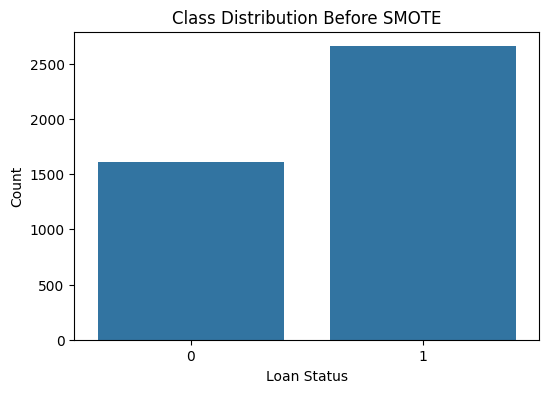

In [541]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='loan_status',
    data=df
)

plt.title('Class Distribution Before SMOTE')

plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [542]:
majority_count = class_counts.max()
minority_count = class_counts.min()

balance_ratio = minority_count / majority_count

print("Majority Class Count:", majority_count)
print("Minority Class Count:", minority_count)
print("Balance Ratio:", balance_ratio)

Majority Class Count: 2656
Minority Class Count: 1613
Balance Ratio: 0.6073042168674698


In [543]:
X = df.drop('loan_status', axis=1)

y = df['loan_status']

In [544]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [545]:
print("Number of Features:", X.shape[1])
print("X Shape:", X.shape)

Number of Features: 11
X Shape: (4269, 11)


In [546]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [547]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (3415, 11)
X_test Shape: (854, 11)
y_train Shape: (3415,)
y_test Shape: (854,)


In [548]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [549]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

In [550]:
print("Data Preprocessing")

print("X_train Shape:", X_train_scaled.shape)
print("X_test Shape:", X_test_scaled.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

Data Preprocessing
X_train Shape: (3415, 11)
X_test Shape: (854, 11)
y_train Shape: (3415,)
y_test Shape: (854,)


In [551]:
print("Before SMOTE:")

print(y_train.value_counts())

Before SMOTE:
loan_status
1    2125
0    1290
Name: count, dtype: int64


In [552]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [553]:
print("After SMOTE:")

print(y_train_smote.value_counts())

After SMOTE:
loan_status
1    2125
0    2125
Name: count, dtype: int64


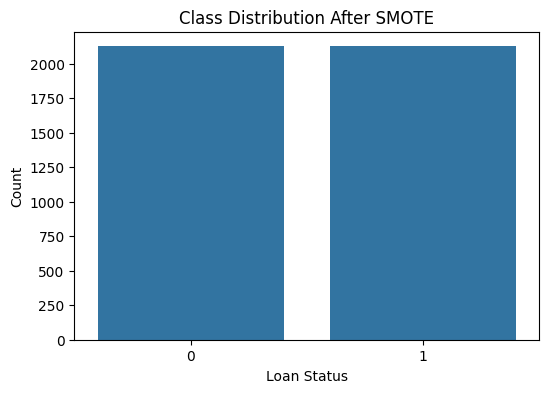

In [554]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y_train_smote
)

plt.title('Class Distribution After SMOTE')

plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [555]:
print("Original Training Set:")
print(y_train.value_counts())

print("\nBalanced Training Set:")
print(y_train_smote.value_counts())

Original Training Set:
loan_status
1    2125
0    1290
Name: count, dtype: int64

Balanced Training Set:
loan_status
1    2125
0    2125
Name: count, dtype: int64


In [556]:
print("1) LOGISTIC REGRESSION")

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

1) LOGISTIC REGRESSION


In [557]:
start_time = time.time()

log_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_log = time.time() - start_time

In [558]:
y_train_pred_log = log_model.predict(
    X_train_smote
)

y_test_pred_log = log_model.predict(
    X_test_scaled
)

y_train_probs_log = log_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_log = log_model.predict_proba(
    X_test_scaled
)[:, 1]

In [559]:
train_acc_log = accuracy_score(
    y_train_smote,
    y_train_pred_log
)

test_acc_log = accuracy_score(
    y_test,
    y_test_pred_log
)

print("Train Accuracy:", train_acc_log)
print("Test Accuracy:", test_acc_log)

Train Accuracy: 0.9272941176470588
Test Accuracy: 0.9227166276346604


In [560]:
manual_train_acc_log = sum(
    y_train_smote == y_train_pred_log
) / len(y_train_smote)

manual_test_acc_log = sum(
    y_test == y_test_pred_log
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_log)
print("Manual Test Accuracy:", manual_test_acc_log)

Manual Train Accuracy: 0.9272941176470588
Manual Test Accuracy: 0.9227166276346604


In [561]:
loss_log_function = log_loss(
    y_test,
    y_test_probs_log
)

print("Log Loss using function:", loss_log_function)

Log Loss using function: 0.20588127750213786


In [562]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_log,
    epsilon,
    1 - epsilon
)

manual_loss_log = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_log)

Manual Log Loss: 0.20588127750213786


In [563]:
recall_log = recall_score(
    y_test,
    y_test_pred_log
)

f1_log = f1_score(
    y_test,
    y_test_pred_log
)

print("Recall Score:", recall_log)
print("F1 Score:", f1_log)

print(
    f"Training Time: {execution_time_log:.4f} seconds"
)

Recall Score: 0.9227871939736346
F1 Score: 0.9369024856596558
Training Time: 0.0133 seconds


In [564]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_log
    )
)

Confusion Matrix
[[298  25]
 [ 41 490]]


In [565]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_log
    )
)

print("Test Accuracy:", test_acc_log)

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       323
           1       0.95      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854

Test Accuracy: 0.9227166276346604


In [566]:
print("2) KNN CLASSIFIER")

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

2) KNN CLASSIFIER


In [567]:
start_time = time.time()

knn_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_knn = time.time() - start_time

In [568]:
y_train_pred_knn = knn_model.predict(
    X_train_smote
)

y_test_pred_knn = knn_model.predict(
    X_test_scaled
)

y_train_probs_knn = knn_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_knn = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

In [569]:
train_acc_knn = accuracy_score(
    y_train_smote,
    y_train_pred_knn
)

test_acc_knn = accuracy_score(
    y_test,
    y_test_pred_knn
)

print("Train Accuracy:", train_acc_knn)
print("Test Accuracy:", test_acc_knn)

Train Accuracy: 0.9463529411764706
Test Accuracy: 0.8899297423887588


In [570]:
manual_train_acc_knn = sum(
    y_train_smote == y_train_pred_knn
) / len(y_train_smote)

manual_test_acc_knn = sum(
    y_test == y_test_pred_knn
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_knn)
print("Manual Test Accuracy:", manual_test_acc_knn)

Manual Train Accuracy: 0.9463529411764706
Manual Test Accuracy: 0.8899297423887588


In [571]:
manual_train_acc_knn = sum(
    y_train_smote == y_train_pred_knn
) / len(y_train_smote)

manual_test_acc_knn = sum(
    y_test == y_test_pred_knn
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_knn)
print("Manual Test Accuracy:", manual_test_acc_knn)

Manual Train Accuracy: 0.9463529411764706
Manual Test Accuracy: 0.8899297423887588


In [572]:
loss_knn_function = log_loss(
    y_test,
    y_test_probs_knn
)

print("Log Loss using function:", loss_knn_function)

Log Loss using function: 0.5382050274786776


In [573]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_knn,
    epsilon,
    1 - epsilon
)

manual_loss_knn = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_knn)

Manual Log Loss: 0.5241106279923067


In [574]:
recall_knn = recall_score(
    y_test,
    y_test_pred_knn
)

f1_knn = f1_score(
    y_test,
    y_test_pred_knn
)

print("Recall Score:", recall_knn)
print("F1 Score:", f1_knn)

print(
    f"Training Time: {execution_time_knn:.4f} seconds"
)

Recall Score: 0.879472693032015
F1 Score: 0.9085603112840467
Training Time: 0.0154 seconds


In [575]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_knn
    )
)

Confusion Matrix
[[293  30]
 [ 64 467]]


In [576]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_knn
    )
)

print("Train Accuracy:", train_acc_knn)
print("Test Accuracy:", test_acc_knn)

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       323
           1       0.94      0.88      0.91       531

    accuracy                           0.89       854
   macro avg       0.88      0.89      0.89       854
weighted avg       0.89      0.89      0.89       854

Train Accuracy: 0.9463529411764706
Test Accuracy: 0.8899297423887588


In [577]:
print("3) DECISION TREE")

tree_model = DecisionTreeClassifier(
    random_state=42
)

3) DECISION TREE


In [578]:
start_time = time.time()

tree_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_tree = time.time() - start_time

In [579]:
y_train_pred_tree = tree_model.predict(
    X_train_smote
)

y_test_pred_tree = tree_model.predict(
    X_test_scaled
)

y_train_probs_tree = tree_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_tree = tree_model.predict_proba(
    X_test_scaled
)[:, 1]

In [580]:
train_acc_tree = accuracy_score(
    y_train_smote,
    y_train_pred_tree
)

test_acc_tree = accuracy_score(
    y_test,
    y_test_pred_tree
)

print("Train Accuracy:", train_acc_tree)
print("Test Accuracy:", test_acc_tree)

Train Accuracy: 1.0
Test Accuracy: 0.9812646370023419


In [581]:
manual_train_acc_tree = sum(
    y_train_smote == y_train_pred_tree
) / len(y_train_smote)

manual_test_acc_tree = sum(
    y_test == y_test_pred_tree
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_tree)
print("Manual Test Accuracy:", manual_test_acc_tree)

Manual Train Accuracy: 1.0
Manual Test Accuracy: 0.9812646370023419


In [582]:
loss_tree_function = log_loss(
    y_test,
    y_test_probs_tree
)

print("Log Loss using function:", loss_tree_function)

Log Loss using function: 0.675290930006879


In [583]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_tree,
    epsilon,
    1 - epsilon
)

manual_loss_tree = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_tree)

Manual Log Loss: 0.6471058762211636


In [584]:
recall_tree = recall_score(
    y_test,
    y_test_pred_tree
)

f1_tree = f1_score(
    y_test,
    y_test_pred_tree
)

print("Recall Score:", recall_tree)
print("F1 Score:", f1_tree)

print(
    f"Training Time: {execution_time_tree:.4f} seconds"
)

Recall Score: 0.9887005649717514
F1 Score: 0.9849906191369606
Training Time: 0.0246 seconds


In [585]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_tree
    )
)

Confusion Matrix
[[313  10]
 [  6 525]]


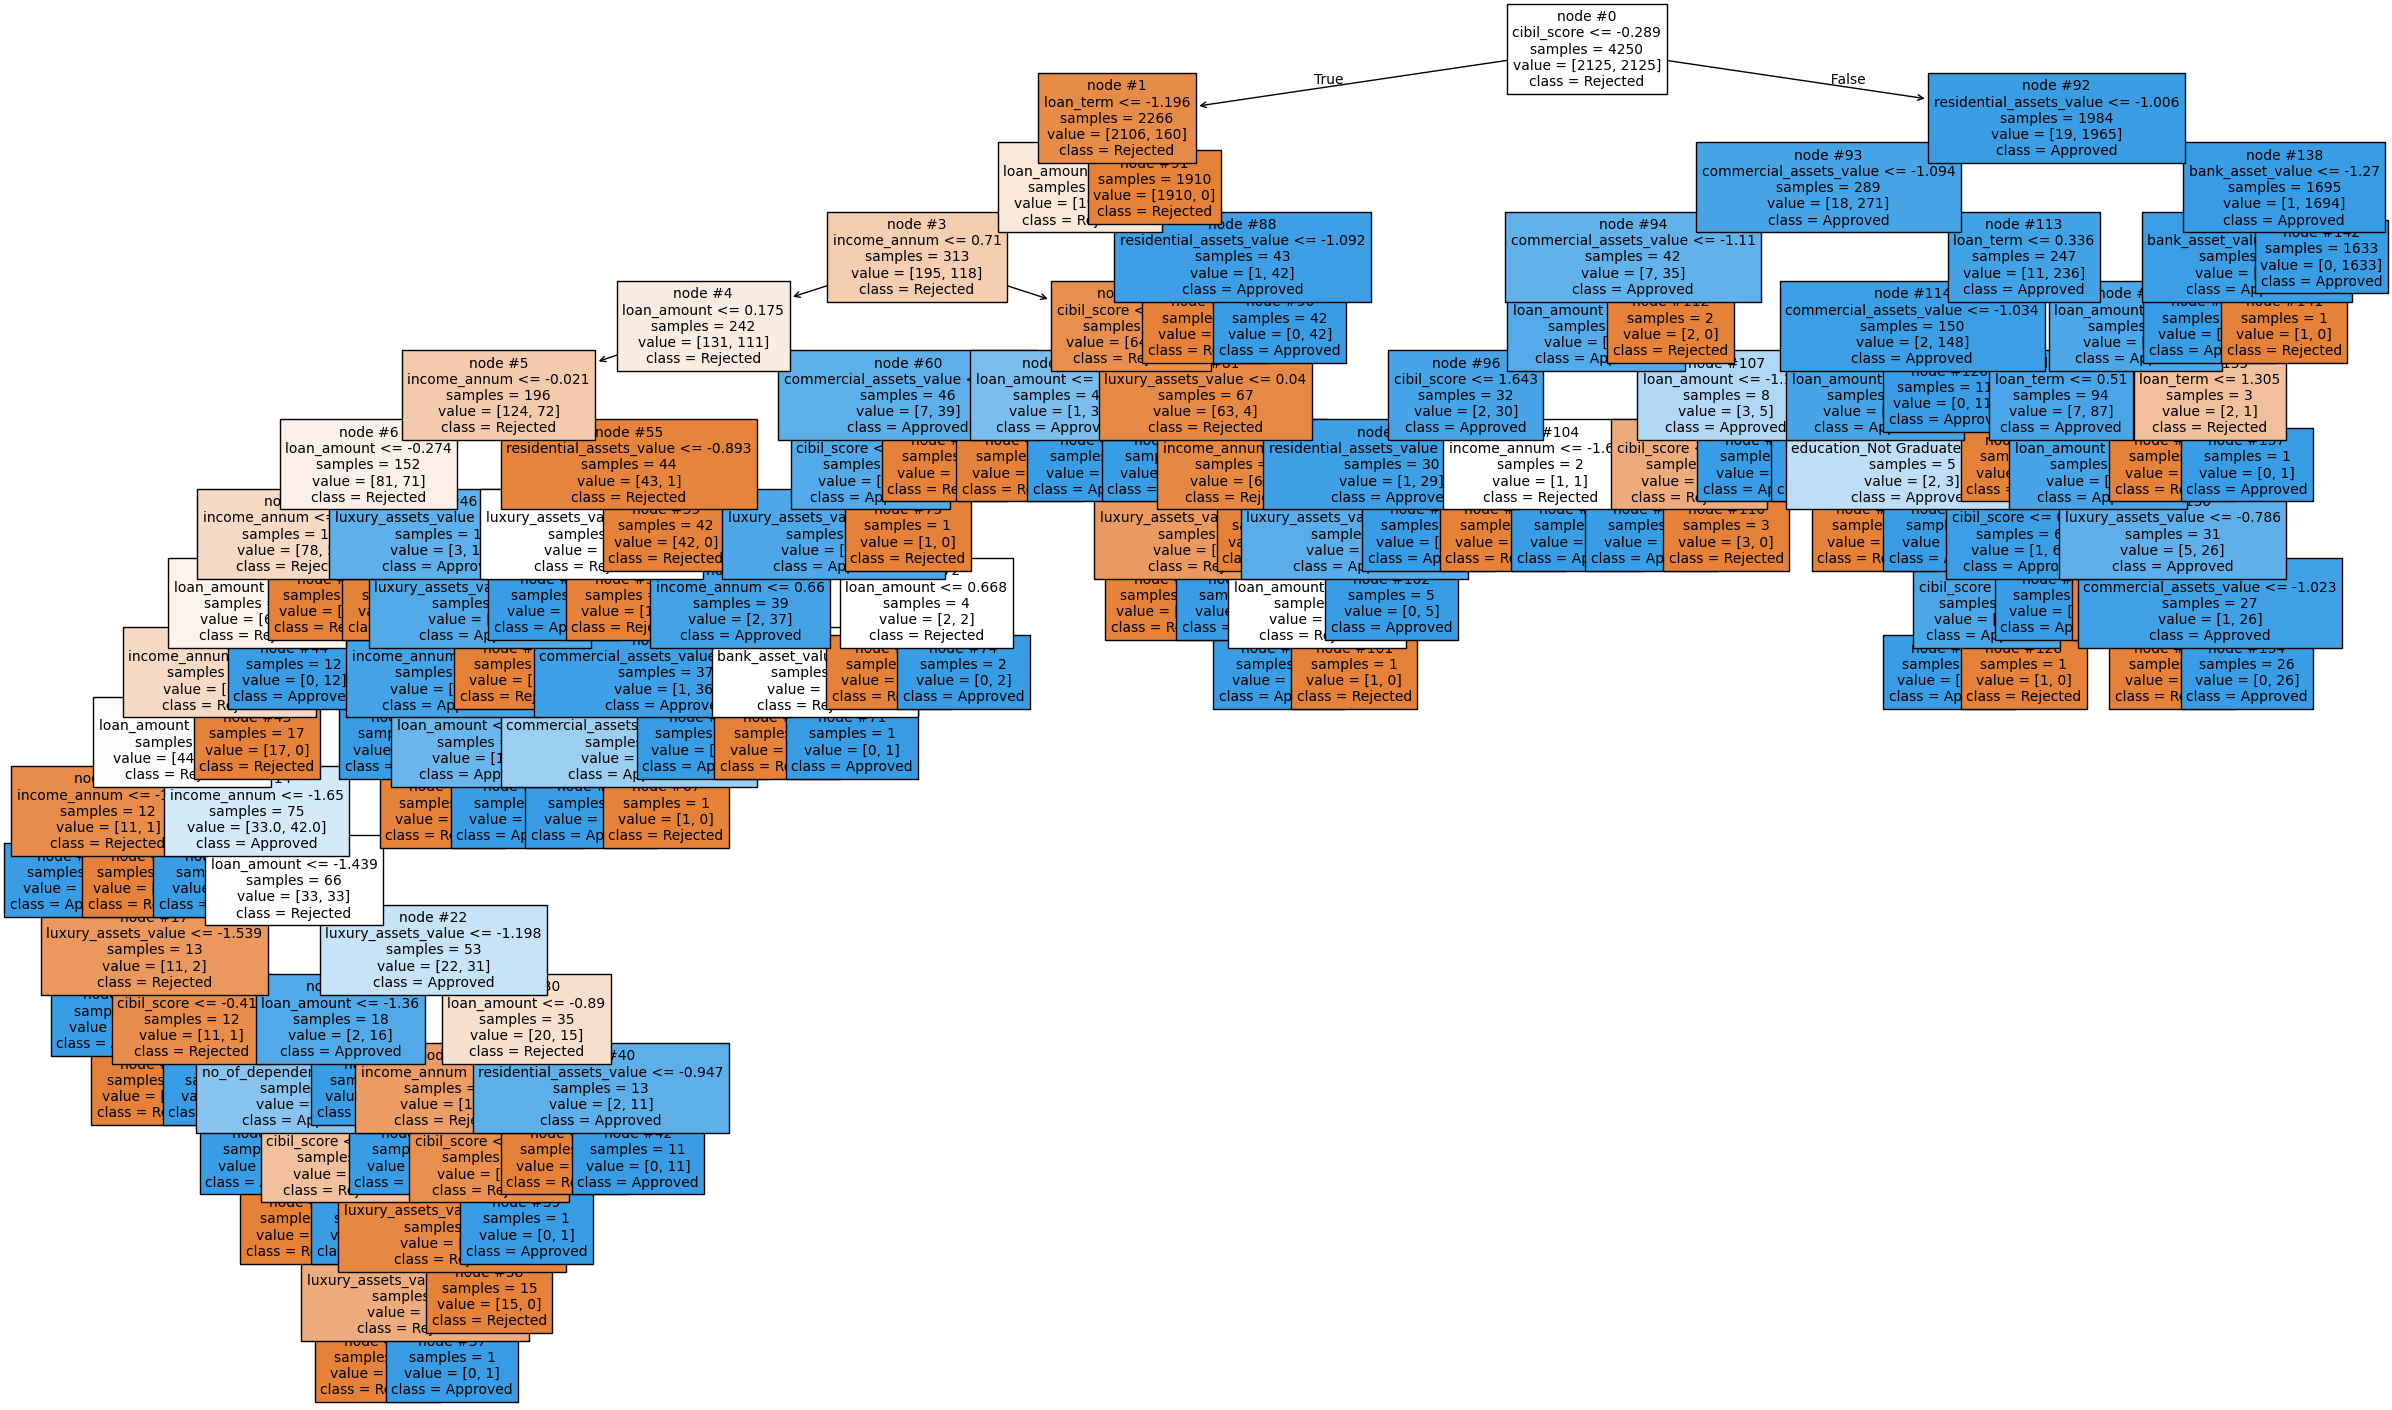

In [586]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(30, 18))

tree.plot_tree(
    tree_model,
    filled=True,
    node_ids=True,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    impurity=False,
    fontsize=10
)

plt.show()

In [587]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_tree
    )
)

print("Train Accuracy:", train_acc_tree)
print("Test Accuracy:", test_acc_tree)

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Train Accuracy: 1.0
Test Accuracy: 0.9812646370023419


In [588]:
print("4) RANDOM FOREST")

rf_model= RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_depth=5,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

4) RANDOM FOREST


RandomForestClassifier(criterion='entropy', max_depth=5, random_state=42)

In [589]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=42)

In [590]:
y_pred = rf_model.predict(X_test)

print(y_pred)

[1 0 0 1 1 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1
 1 1 0 0 1 0 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1
 1 0 1 0 1 1 0 0 1 0 1 1 1 0 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 1 0
 0 0 1 1 0 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1
 0 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1
 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 1 1 0 1
 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1
 0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0
 0 0 1 1 1 1 0 1 0 1 0 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 1 0
 0 0 1 1 1 1 1 1 1 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1
 1 1 0 0 1 0 1 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 0
 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1
 1 1 1 1 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1
 1 1 1 1 1 0 0 1 0 0 1 0 

In [591]:
start_time = time.time()

rf_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_rf = time.time() - start_time

In [592]:
y_train_pred_rf = rf_model.predict(
    X_train_smote
)

y_test_pred_rf = rf_model.predict(
    X_test_scaled
)

y_train_probs_rf = rf_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_rf = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

In [593]:
train_acc_rf = accuracy_score(
    y_train_smote,
    y_train_pred_rf
)

test_acc_rf = accuracy_score(
    y_test,
    y_test_pred_rf
)

print("Train Accuracy:", train_acc_rf)
print("Test Accuracy:", test_acc_rf)

Train Accuracy: 0.9755294117647059
Test Accuracy: 0.9742388758782201


In [594]:
manual_train_acc_rf = sum(
    y_train_smote == y_train_pred_rf
) / len(y_train_smote)

manual_test_acc_rf = sum(
    y_test == y_test_pred_rf
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_rf)
print("Manual Test Accuracy:", manual_test_acc_rf)

Manual Train Accuracy: 0.9755294117647059
Manual Test Accuracy: 0.9742388758782201


In [595]:
loss_rf_function = log_loss(
    y_test,
    y_test_probs_rf
)

print("Log Loss using function:", loss_rf_function)

Log Loss using function: 0.15284784707085305


In [596]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_rf,
    epsilon,
    1 - epsilon
)

manual_loss_rf = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_rf)

Manual Log Loss: 0.15284784707085305


In [597]:
recall_rf = recall_score(
    y_test,
    y_test_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_test_pred_rf
)

print("Recall Score:", recall_rf)
print("F1 Score:", f1_rf)

print(
    f"Training Time: {execution_time_rf:.4f} seconds"
)

Recall Score: 0.9698681732580038
F1 Score: 0.9790874524714829
Training Time: 1.3685 seconds


In [598]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_rf
    )
)

Confusion Matrix
[[317   6]
 [ 16 515]]


In [599]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_rf
    )
)

print("Train Accuracy:", train_acc_rf)
print("Test Accuracy:", test_acc_rf)

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       323
           1       0.99      0.97      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.98      0.97       854
weighted avg       0.97      0.97      0.97       854

Train Accuracy: 0.9755294117647059
Test Accuracy: 0.9742388758782201


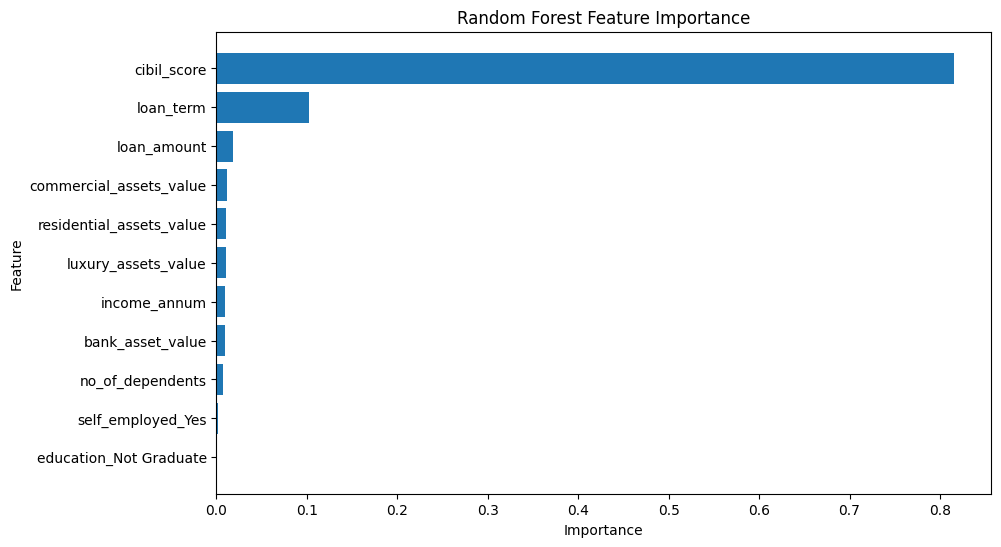

In [600]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.show()

In [601]:
print("5) SVM (LINEAR KERNEL)")

svm_linear_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

5) SVM (LINEAR KERNEL)


In [602]:
linear_clf = SVC(
    kernel="linear",
    C=1
)

# Refit the linear_clf model using only the two features selected for plotting
linear_clf.fit(X_train_smote[['cibil_score', 'loan_term']], y_train_smote)

SVC(C=1, kernel='linear')

In [603]:
start_time = time.time()

svm_linear_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_svm_linear = time.time() - start_time

In [604]:
y_train_pred_svm_linear = svm_linear_model.predict(
    X_train_smote
)

y_test_pred_svm_linear = svm_linear_model.predict(
    X_test_scaled
)

y_test_probs_svm_linear = svm_linear_model.predict_proba(
    X_test_scaled
)[:, 1]

In [605]:
train_acc_svm_linear = accuracy_score(
    y_train_smote,
    y_train_pred_svm_linear
)

test_acc_svm_linear = accuracy_score(
    y_test,
    y_test_pred_svm_linear
)

print("Train Accuracy:", train_acc_svm_linear)
print("Test Accuracy:", test_acc_svm_linear)

Train Accuracy: 0.9371764705882353
Test Accuracy: 0.9297423887587822


In [606]:
manual_train_acc_svm_linear = sum(
    y_train_smote == y_train_pred_svm_linear
) / len(y_train_smote)

manual_test_acc_svm_linear = sum(
    y_test == y_test_pred_svm_linear
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_svm_linear)
print("Manual Test Accuracy:", manual_test_acc_svm_linear)

Manual Train Accuracy: 0.9371764705882353
Manual Test Accuracy: 0.9297423887587822


In [607]:
decision_values_test = svm_linear_model.decision_function(
    X_test_scaled
)

print("Decision Values:")

print(decision_values_test)

Decision Values:
[ 2.90199662e+00 -3.15605309e+00 -1.44915310e-01  2.28822519e+00
  2.70767894e+00  5.52180207e+00  4.13823744e+00 -1.06384296e+00
  1.04498469e+00 -2.34602939e+00 -3.66342488e+00 -4.56583705e+00
  3.57222200e+00 -2.94554382e+00  2.48724212e+00 -5.01190949e+00
 -2.75448713e-01 -1.02549234e-01  3.11459887e+00 -5.18146212e+00
  5.69184584e+00  4.45345546e+00  2.13209767e+00  5.34688715e+00
  5.47596844e+00 -2.25798767e-01  9.90020705e-01 -2.69264905e-01
  3.39125392e+00  2.53045824e+00  6.80938179e+00 -6.81879614e-01
  3.27900364e+00  2.38580154e+00 -8.92629472e-01  6.16860831e+00
  5.67223327e-01 -3.51386803e+00  4.82535708e+00 -2.18013019e+00
 -4.56208942e+00  2.88066886e+00 -7.83840708e-01  6.51213052e-01
  6.64132231e-01  1.88641715e+00  2.89686398e+00 -5.07747457e-01
 -3.35835510e+00  3.80537583e+00  1.45802166e+00 -4.71547347e-01
  2.42090002e+00  9.17082583e-01 -6.85650003e-01 -3.76589717e+00
  3.49705963e+00 -2.91884501e+00  2.75794392e-02  1.66145945e+00
  3.8796

In [608]:
y_test_svm = np.where(
    y_test == 1,
    1,
    -1
)

hinge_loss_function = hinge_loss(
    y_test_svm,
    decision_values_test
)

print(
    "Hinge Loss using function:",
    hinge_loss_function
)

Hinge Loss using function: 0.19993496170861505


In [609]:
hinge_losses = np.maximum(
    0,
    1 - y_test_svm * decision_values_test
)

manual_hinge_loss = np.mean(
    hinge_losses
)

print(
    "Manual Hinge Loss:",
    manual_hinge_loss
)

Manual Hinge Loss: 0.19993496170861505


In [610]:
recall_svm_linear = recall_score(
    y_test,
    y_test_pred_svm_linear
)

f1_svm_linear = f1_score(
    y_test,
    y_test_pred_svm_linear
)

print("Recall Score:", recall_svm_linear)
print("F1 Score:", f1_svm_linear)

print(
    f"Training Time: {execution_time_svm_linear:.4f} seconds"
)

Recall Score: 0.9227871939736346
F1 Score: 0.9423076923076923
Training Time: 4.6045 seconds


In [611]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_svm_linear
    )
)

Confusion Matrix
[[304  19]
 [ 41 490]]


In [612]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_svm_linear
    )
)

print("Train Accuracy:", train_acc_svm_linear)
print("Test Accuracy:", test_acc_svm_linear)

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       323
           1       0.96      0.92      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.93       854
weighted avg       0.93      0.93      0.93       854

Train Accuracy: 0.9371764705882353
Test Accuracy: 0.9297423887587822


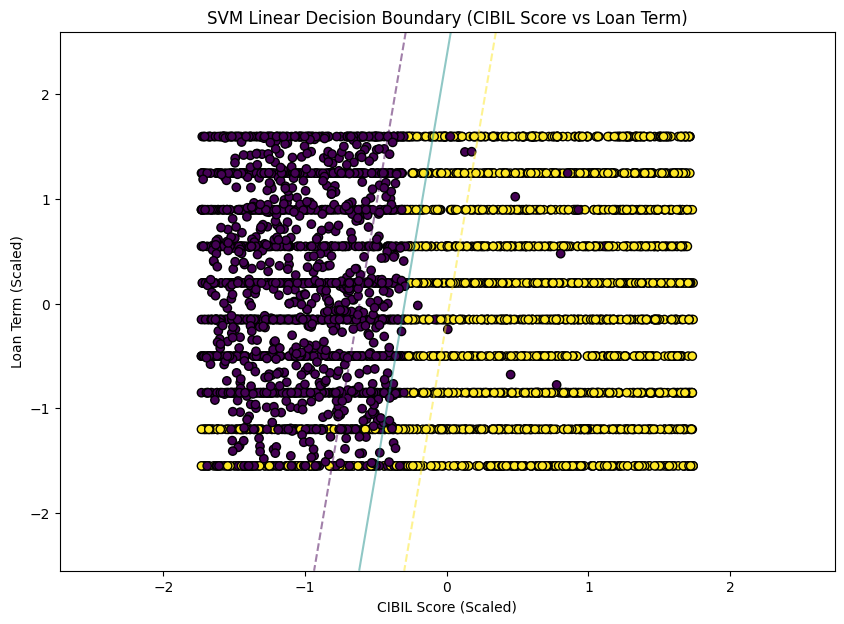

In [613]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
plt.figure(figsize=(10, 7))
X_train_smote_2d = X_train_smote[['cibil_score', 'loan_term']]
DecisionBoundaryDisplay.from_estimator(
    linear_clf,
    X_train_smote_2d,
    plot_method="contour",
    response_method="decision_function",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    alpha=0.5,
    ax=plt.gca()
)
plt.scatter(
    X_train_smote_2d.iloc[:, 0],
    X_train_smote_2d.iloc[:, 1],
    c=y_train_smote,
    edgecolors="k"
)
plt.xlabel("CIBIL Score (Scaled)")
plt.ylabel("Loan Term (Scaled)")
plt.title("SVM Linear Decision Boundary (CIBIL Score vs Loan Term)")

plt.show()

In [614]:
print("6) SVM (RBF KERNEL)")

svm_rbf_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

6) SVM (RBF KERNEL)


In [615]:
start_time = time.time()

svm_rbf_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_svm_rbf = time.time() - start_time

In [616]:
y_train_pred_svm_rbf = svm_rbf_model.predict(
    X_train_smote
)

y_test_pred_svm_rbf = svm_rbf_model.predict(
    X_test_scaled
)

y_train_probs_svm_rbf = svm_rbf_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_svm_rbf = svm_rbf_model.predict_proba(
    X_test_scaled
)[:, 1]

In [617]:
train_acc_svm_rbf = accuracy_score(
    y_train_smote,
    y_train_pred_svm_rbf
)

test_acc_svm_rbf = accuracy_score(
    y_test,
    y_test_pred_svm_rbf
)

print("Train Accuracy:", train_acc_svm_rbf)
print("Test Accuracy:", test_acc_svm_rbf)

Train Accuracy: 0.9585882352941176
Test Accuracy: 0.9379391100702577


In [618]:
manual_train_acc_svm_rbf = sum(
    y_train_smote == y_train_pred_svm_rbf
) / len(y_train_smote)

manual_test_acc_svm_rbf = sum(
    y_test == y_test_pred_svm_rbf
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_svm_rbf)
print("Manual Test Accuracy:", manual_test_acc_svm_rbf)

Manual Train Accuracy: 0.9585882352941176
Manual Test Accuracy: 0.9379391100702577


In [619]:
loss_svm_rbf_function = log_loss(
    y_test,
    y_test_probs_svm_rbf
)

print(
    "Log Loss using function:",
    loss_svm_rbf_function
)

Log Loss using function: 0.15089456005232177


In [620]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_svm_rbf,
    epsilon,
    1 - epsilon
)

manual_loss_svm_rbf = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_svm_rbf)

Manual Log Loss: 0.15089456005232177


In [621]:
recall_svm_rbf = recall_score(
    y_test,
    y_test_pred_svm_rbf
)

f1_svm_rbf = f1_score(
    y_test,
    y_test_pred_svm_rbf
)

print("Recall Score:", recall_svm_rbf)
print("F1 Score:", f1_svm_rbf)

print(
    f"Training Time: {execution_time_svm_rbf:.4f} seconds"
)

Recall Score: 0.9340866290018832
F1 Score: 0.9492822966507177
Training Time: 2.9584 seconds


In [622]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_svm_rbf
    )
)

Confusion Matrix
[[305  18]
 [ 35 496]]


In [623]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_svm_rbf
    )
)

print("Train Accuracy:", train_acc_svm_rbf)
print("Test Accuracy:", test_acc_svm_rbf)

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       323
           1       0.96      0.93      0.95       531

    accuracy                           0.94       854
   macro avg       0.93      0.94      0.93       854
weighted avg       0.94      0.94      0.94       854

Train Accuracy: 0.9585882352941176
Test Accuracy: 0.9379391100702577


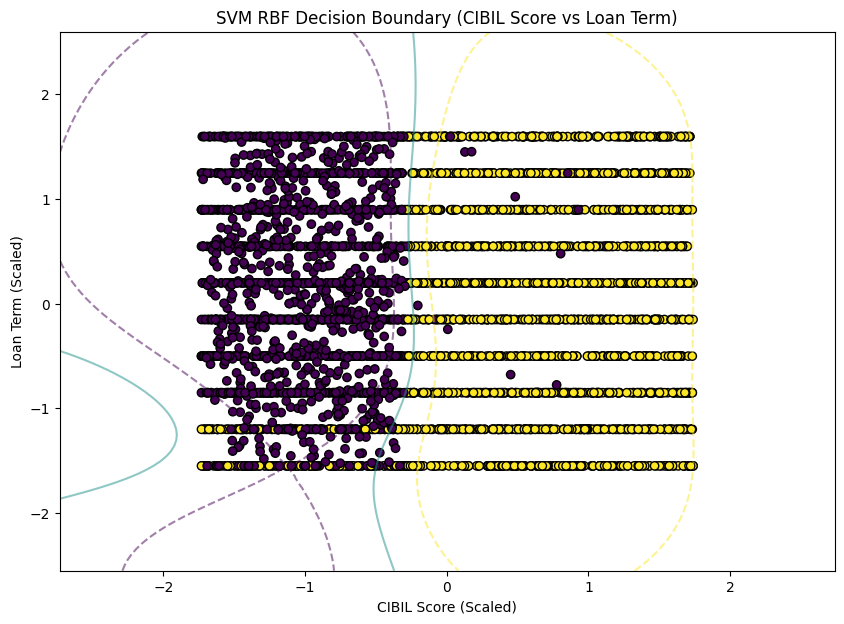

In [624]:
plt.figure(figsize=(10, 7))
X_train_scaled_2d = X_train_smote[['cibil_score', 'loan_term']]

# Create and train a new RBF SVM model specifically for 2D plotting
rbf_clf_2d = SVC(kernel='rbf', probability=True, random_state=42)
rbf_clf_2d.fit(X_train_scaled_2d, y_train_smote)

DecisionBoundaryDisplay.from_estimator(
    rbf_clf_2d,
    X_train_scaled_2d,
    plot_method="contour",
    response_method="decision_function",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    alpha=0.5,
    ax=plt.gca()
)
plt.scatter(
    X_train_scaled_2d.iloc[:, 0],
    X_train_scaled_2d.iloc[:, 1],
    c=y_train_smote,
    edgecolors="k"
)
plt.xlabel("CIBIL Score (Scaled)")
plt.ylabel("Loan Term (Scaled)")
plt.title("SVM RBF Decision Boundary (CIBIL Score vs Loan Term)")

plt.show()

In [625]:
print("7) ADABOOST CLASSIFIER")

ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

7) ADABOOST CLASSIFIER


In [626]:
start_time = time.time()

ada_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_ada = time.time() - start_time

In [627]:
y_train_pred_ada = ada_model.predict(
    X_train_smote
)

y_test_pred_ada = ada_model.predict(
    X_test_scaled
)

y_train_probs_ada = ada_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_ada = ada_model.predict_proba(
    X_test_scaled
)[:, 1]

In [628]:
train_acc_ada = accuracy_score(
    y_train_smote,
    y_train_pred_ada
)

test_acc_ada = accuracy_score(
    y_test,
    y_test_pred_ada
)

print("Train Accuracy:", train_acc_ada)
print("Test Accuracy:", test_acc_ada)

Train Accuracy: 0.9778823529411764
Test Accuracy: 0.9730679156908665


In [629]:
manual_train_acc_ada = sum(
    y_train_smote == y_train_pred_ada
) / len(y_train_smote)

manual_test_acc_ada = sum(
    y_test == y_test_pred_ada
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_ada)
print("Manual Test Accuracy:", manual_test_acc_ada)

Manual Train Accuracy: 0.9778823529411764
Manual Test Accuracy: 0.9730679156908665


In [630]:
loss_ada_function = log_loss(
    y_test,
    y_test_probs_ada
)

print(
    "Log Loss using function:",
    loss_ada_function
)

Log Loss using function: 0.46829458328399653


In [631]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_ada,
    epsilon,
    1 - epsilon
)

manual_loss_ada = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_ada)

Manual Log Loss: 0.46829458328399653


In [632]:
recall_ada = recall_score(
    y_test,
    y_test_pred_ada
)

f1_ada = f1_score(
    y_test,
    y_test_pred_ada
)

print("Recall Score:", recall_ada)
print("F1 Score:", f1_ada)

print(
    f"Training Time: {execution_time_ada:.4f} seconds"
)

Recall Score: 0.975517890772128
F1 Score: 0.9782813975448537
Training Time: 1.8075 seconds


In [633]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_ada
    )
)

Confusion Matrix
[[313  10]
 [ 13 518]]


In [634]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_ada
    )
)

print("Train Accuracy:", train_acc_ada)
print("Test Accuracy:", test_acc_ada)

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       323
           1       0.98      0.98      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

Train Accuracy: 0.9778823529411764
Test Accuracy: 0.9730679156908665


In [635]:
print("8) XGBOOST CLASSIFIER")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

8) XGBOOST CLASSIFIER


In [636]:
start_time = time.time()

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_xgb = time.time() - start_time

In [637]:
y_train_pred_xgb = xgb_model.predict(
    X_train_smote
)

y_test_pred_xgb = xgb_model.predict(
    X_test_scaled
)

y_train_probs_xgb = xgb_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:, 1]

In [638]:
train_acc_xgb = accuracy_score(
    y_train_smote,
    y_train_pred_xgb
)

test_acc_xgb = accuracy_score(
    y_test,
    y_test_pred_xgb
)

print("Train Accuracy:", train_acc_xgb)
print("Test Accuracy:", test_acc_xgb)

Train Accuracy: 0.9990588235294118
Test Accuracy: 0.9836065573770492


In [639]:
manual_train_acc_xgb = sum(
    y_train_smote == y_train_pred_xgb
) / len(y_train_smote)

manual_test_acc_xgb = sum(
    y_test == y_test_pred_xgb
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_xgb)
print("Manual Test Accuracy:", manual_test_acc_xgb)

Manual Train Accuracy: 0.9990588235294118
Manual Test Accuracy: 0.9836065573770492


In [640]:
loss_xgb_function = log_loss(
    y_test,
    y_test_probs_xgb
)

print(
    "Log Loss using function:",
    loss_xgb_function
)

Log Loss using function: 0.04567114975212781


In [641]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_xgb,
    epsilon,
    1 - epsilon
)

manual_loss_xgb = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_xgb)

Manual Log Loss: 0.04567115012467299


In [642]:
recall_xgb = recall_score(
    y_test,
    y_test_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_test_pred_xgb
)

print("Recall Score:", recall_xgb)
print("F1 Score:", f1_xgb)

print(
    f"Training Time: {execution_time_xgb:.4f} seconds"
)

Recall Score: 0.9868173258003766
F1 Score: 0.9868173258003766
Training Time: 2.6415 seconds


In [643]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_xgb
    )
)

Confusion Matrix
[[316   7]
 [  7 524]]


In [644]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_xgb
    )
)

print("Train Accuracy:", train_acc_xgb)
print("Test Accuracy:", test_acc_xgb)

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Train Accuracy: 0.9990588235294118
Test Accuracy: 0.9836065573770492


In [645]:
print("9) CATBOOST CLASSIFIER")

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

9) CATBOOST CLASSIFIER


In [646]:
start_time = time.time()

cat_model.fit(
    X_train_smote,
    y_train_smote
)

execution_time_cat = time.time() - start_time

In [647]:
y_train_pred_cat = cat_model.predict(
    X_train_smote
)

y_test_pred_cat = cat_model.predict(
    X_test_scaled
)

y_train_probs_cat = cat_model.predict_proba(
    X_train_smote
)[:, 1]

y_test_probs_cat = cat_model.predict_proba(
    X_test_scaled
)[:, 1]

In [648]:
train_acc_cat = accuracy_score(
    y_train_smote,
    y_train_pred_cat
)

test_acc_cat = accuracy_score(
    y_test,
    y_test_pred_cat
)

print("Train Accuracy:", train_acc_cat)
print("Test Accuracy:", test_acc_cat)

Train Accuracy: 0.9901176470588235
Test Accuracy: 0.9789227166276346


In [649]:
manual_train_acc_cat = sum(
    y_train_smote == y_train_pred_cat
) / len(y_train_smote)

manual_test_acc_cat = sum(
    y_test == y_test_pred_cat
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_cat)
print("Manual Test Accuracy:", manual_test_acc_cat)

Manual Train Accuracy: 0.9901176470588235
Manual Test Accuracy: 0.9789227166276346


In [650]:
loss_cat_function = log_loss(
    y_test,
    y_test_probs_cat
)

print(
    "Log Loss using function:",
    loss_cat_function
)

Log Loss using function: 0.05776659394908264


In [651]:
epsilon = 1e-15

p = np.clip(
    y_test_probs_cat,
    epsilon,
    1 - epsilon
)

manual_loss_cat = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

print("Manual Log Loss:", manual_loss_cat)

Manual Log Loss: 0.05776659394908264


In [652]:
recall_cat = recall_score(
    y_test,
    y_test_pred_cat
)

f1_cat = f1_score(
    y_test,
    y_test_pred_cat
)

print("Recall Score:", recall_cat)
print("F1 Score:", f1_cat)

print(
    f"Training Time: {execution_time_cat:.4f} seconds"
)

Recall Score: 0.9792843691148776
F1 Score: 0.9829867674858223
Training Time: 0.5593 seconds


In [653]:
print("Confusion Matrix")

print(
    confusion_matrix(
        y_test,
        y_test_pred_cat
    )
)

Confusion Matrix
[[316   7]
 [ 11 520]]


In [654]:
print("Classification Report")

print(
    classification_report(
        y_test,
        y_test_pred_cat
    )
)

print("Train Accuracy:", train_acc_cat)
print("Test Accuracy:", test_acc_cat)

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       323
           1       0.99      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Train Accuracy: 0.9901176470588235
Test Accuracy: 0.9789227166276346


In [655]:
print("10) LIGHTGBM CLASSIFIER")

from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1)

10) LIGHTGBM CLASSIFIER


In [656]:
start_time = time.time()

lgb_model.fit(
    X_train_scaled,
    y_train
)

execution_time_lgb = time.time() - start_time

In [657]:
y_train_pred_lgb = lgb_model.predict(
    X_train_scaled
)

y_test_pred_lgb = lgb_model.predict(
    X_test_scaled
)

y_test_probs_lgb = lgb_model.predict_proba(
    X_test_scaled
)[:, 1]

In [658]:
train_acc_lgb = accuracy_score(
    y_train,
    y_train_pred_lgb
)

test_acc_lgb = accuracy_score(
    y_test,
    y_test_pred_lgb
)

print("Train Accuracy:", train_acc_lgb)
print("Test Accuracy:", test_acc_lgb)

Train Accuracy: 1.0
Test Accuracy: 0.9871194379391101


In [659]:
manual_train_acc_lgb = sum(
    y_train == y_train_pred_lgb
) / len(y_train)

manual_test_acc_lgb = sum(
    y_test == y_test_pred_lgb
) / len(y_test)

print("Manual Train Accuracy:", manual_train_acc_lgb)
print("Manual Test Accuracy:", manual_test_acc_lgb)

Manual Train Accuracy: 1.0
Manual Test Accuracy: 0.9871194379391101


In [660]:
recall_lgb = recall_score(
    y_test,
    y_test_pred_lgb
)
print("Recall Score:", recall_lgb)

Recall Score: 0.992467043314501


In [661]:
f1_lgb = f1_score(
    y_test,
    y_test_pred_lgb
)
print("F1 Score:", f1_lgb)

F1 Score: 0.9896713615023475


In [662]:
loss_lgb = log_loss(
    y_test,
    y_test_probs_lgb
)
print("Log Loss:", loss_lgb)

Log Loss: 0.04251429922310625


In [663]:
loss_lgb = log_loss(
    y_test,
    y_test_probs_lgb
)

epsilon = 1e-15

p = np.clip(
    y_test_probs_lgb,
    epsilon,
    1 - epsilon
)

manual_loss_lgb = -np.mean(
    y_test * np.log(p)
    +
    (1 - y_test) * np.log(1 - p)
)

In [664]:
summary_data = {

    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM Linear',
        'SVM RBF',
        'AdaBoost',
        'XGBoost',
        'CatBoost',
        'lightboost'
    ],

    'Train Accuracy': [
        train_acc_log,
        train_acc_knn,
        train_acc_tree,
        train_acc_rf,
        train_acc_svm_linear,
        train_acc_svm_rbf,
        train_acc_ada,
        train_acc_xgb,
        train_acc_cat,
        train_acc_lgb
    ],

    'Test Accuracy': [
        test_acc_log,
        test_acc_knn,
        test_acc_tree,
        test_acc_rf,
        test_acc_svm_linear,
        test_acc_svm_rbf,
        test_acc_ada,
        test_acc_xgb,
        test_acc_cat,
        test_acc_lgb
    ],

    'Recall': [
        recall_log,
        recall_knn,
        recall_tree,
        recall_rf,
        recall_svm_linear,
        recall_svm_rbf,
        recall_ada,
        recall_xgb,
        recall_cat,
        recall_lgb
    ],

    'F1 Score': [
        f1_log,
        f1_knn,
        f1_tree,
        f1_rf,
        f1_svm_linear,
        f1_svm_rbf,
        f1_ada,
        recall_xgb * 0 + f1_xgb,
        f1_cat,
        f1_lgb
    ],

    'Loss': [
        loss_log_function,
        loss_knn_function,
        loss_tree_function,
        loss_rf_function,
        hinge_loss_function,
        loss_svm_rbf_function,
        loss_ada_function,
        loss_xgb_function,
        loss_cat_function,
        loss_lgb
    ],

    'Manual Loss': [
        manual_loss_log,
        manual_loss_knn,
        manual_loss_tree,
        manual_loss_rf,
        manual_hinge_loss,
        manual_loss_svm_rbf,
        manual_loss_ada,
        manual_loss_xgb,
        manual_loss_cat,
        manual_loss_lgb
    ],

    'Training Time': [
        execution_time_log,
        execution_time_knn,
        execution_time_tree,
        execution_time_rf,
        execution_time_svm_linear,
        execution_time_svm_rbf,
        execution_time_ada,
        execution_time_xgb,
        execution_time_cat,
        execution_time_lgb
    ]
}

df_summary = pd.DataFrame(summary_data)

df_summary

,Model,Train Accuracy,Test Accuracy,Recall,F1 Score,Loss,Manual Loss,Training Time
0,Logistic Regression,0.927294,0.922717,0.922787,0.936902,0.205881,0.205881,0.013344
1,KNN,0.946353,0.889930,0.879473,0.908560,0.538205,0.524111,0.015376
2,Decision Tree,1.000000,0.981265,0.988701,0.984991,0.675291,0.647106,0.024564
3,Random Forest,0.975529,0.974239,0.969868,0.979087,0.152848,0.152848,1.368457
4,SVM Linear,0.937176,0.929742,0.922787,0.942308,0.199935,0.199935,4.604497
5,SVM RBF,0.958588,0.937939,0.934087,0.949282,0.150895,0.150895,2.958372
6,AdaBoost,0.977882,0.973068,0.975518,0.978281,0.468295,0.468295,1.807458
7,XGBoost,0.999059,0.983607,0.986817,0.986817,0.045671,0.045671,2.641542
8,CatBoost,0.990118,0.978923,0.979284,0.982987,0.057767,0.057767,0.559345
9,lightboost,1.000000,0.987119,0.992467,0.989671,0.042514,0.042514,0.187173


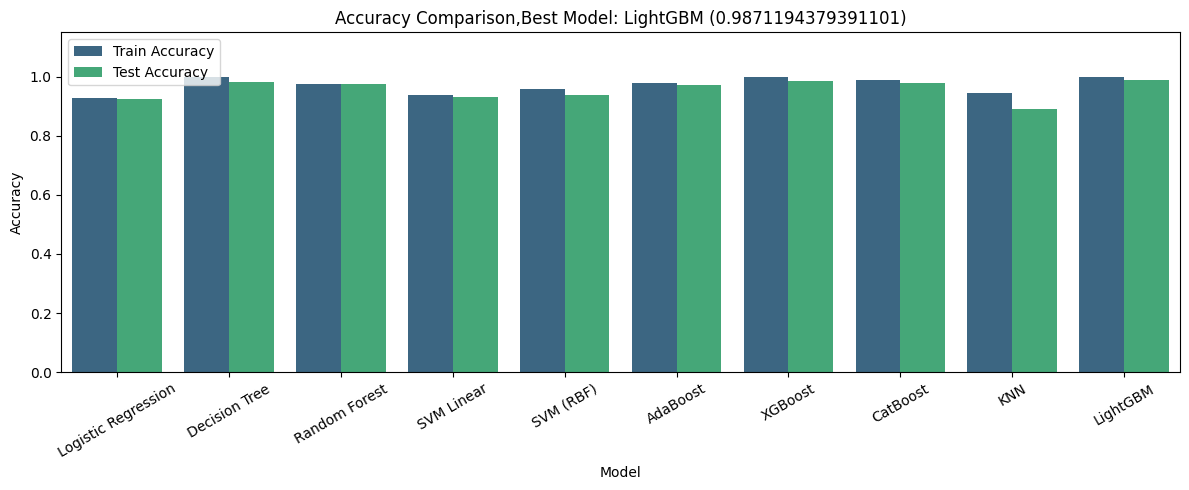

In [665]:
df_plt = pd.DataFrame({
    'Model': [
        'Logistic Regression', 'Decision Tree', 'Random Forest',
        'SVM Linear', 'SVM (RBF)', 'AdaBoost',
        'XGBoost', 'CatBoost', 'KNN', 'LightGBM'
    ],
    'Train Accuracy': [
        train_acc_log, train_acc_tree, train_acc_rf,
        train_acc_svm_linear, train_acc_svm_rbf, train_acc_ada,
        train_acc_xgb, train_acc_cat, train_acc_knn, train_acc_lgb
    ],
    'Test Accuracy': [
        test_acc_log, test_acc_tree, test_acc_rf,
        test_acc_svm_linear, test_acc_svm_rbf, test_acc_ada,
        test_acc_xgb, test_acc_cat, test_acc_knn, test_acc_lgb
    ]
})
best_model = df_plt.loc[df_plt['Test Accuracy'].idxmax()]
df_melted = pd.melt(
    df_plt,
    id_vars=['Model'],
    value_vars=['Train Accuracy', 'Test Accuracy'],
    var_name='Accuracy Type',
    value_name='Accuracy'
)
plt.figure(figsize=(12, 5))
sns.barplot(data=df_melted, x='Model', y='Accuracy', hue='Accuracy Type', palette='viridis')

plt.title(f"Accuracy Comparison,Best Model: {best_model['Model']} ({best_model['Test Accuracy']})")
plt.xticks(rotation=30)
plt.ylim(0, 1.15)
plt.legend()
plt.tight_layout()
plt.show()